# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

- A linear model is a model that is linear in its parameters. In a linear model, the dependent variable is expressed as a linear combination of the parameters multiplied by functions of the independent variables. The model is considered linear as long as it is linear in coefficients, as in it only has one independent variable.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

- A dummy variable takes the value of either 0 or 1 to represent membership in a category. Its coefficient captures how the expected value of the dependent variable differs from the omitted category, which serves as the baseline. The intercept corresponds to this baseline group, and the dummy’s coefficient shows how much the predicted outcome shifts when the variable equals 1, holding other factors constant.

3. Can linear regression be used for classification? Explain why, or why not.

- It can be used for classification but not may be appropriate as it does not always values that are valid probabilities.

4. What are signs that your linear model is over-fitting?

- Overfitting occurs when the model performs well during on the training data but not on new data. Other signs include overly complex models, coefficients that are highly sensitive to small changes in the data, and results that vary significantly across different samples.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

- Multicollinearity occurs when an explanatory variable is highly correlated with other predictors, leaving little independent variation to estimate its effect. In a first-stage regression, if one variable can be largely explained by the others, its residual variation is small. As a result, its coefficient in the main regression becomes imprecise, leading to large standard errors and unstable estimates.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

- Nonlinear relationships can be incorporated by transforming the independent variables while keeping the model linear in parameters. Common approaches include adding polynomial terms using logarithmic transformations, or including interaction terms to allow the effect of one variable to depend on another.

7. What is the interpretation of the slope coefficient in a linear regression?

- The slope coefficient represents the expected changes n the dependent variable y for a one-unit increase in the independent variable x, holding all else constant.

8. Compare the train/test split and $k$-fold cross validation.

- A train/test split divides data into a training set for fitting the model and a test set for evaluation It is simple but results can vary depending on the split. K-fold cross validation can splits the data into
k folds, trains k times using different folds as the test set, giving a more reliable estimate of model performance but requiring more computation.

9. How is the $k$ in $k$-fold cross validation typically selected?

- k is usually 5 or 10, balancing computation and accuracy; larger k gives more reliable performance estimates but takes more time.


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

- Manhattan is the most expensive on average.

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

- The intercept is average price in Bronx exactly and each additional coefficient represents how much more expensive that borough is relative to the Bronx. The conditional group means are just the intercept plus its coefficient.

3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

- The intercept is 60.88 and the slope on Review Scores Rating is 1.02. For every one-point increase in review score, the predicted nightly price increases by about $1.02, holding everything else constant. The relationship is positive but weak.

4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

- After adding neighborhood, the slope on Review Scores Rating rises slightly from 1.02 to 1.08. The neighborhood coefficients barely change, suggesting rating and neighborhood are largely uncorrelated

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?

- The slopes on Review Scores Rating vary across boroughs as Manhattan has the steepest relationship at 1.4  and the Bronx the flattest at 0.22. This suggests the effect of ratings on price is not uniform and that higher end markets like Manhattan may reward higher ratings more.

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import urllib.request
import os
import zipfile
import os


In [2]:

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


    neighborhood  mean_price  mean_rating  count
2      Manhattan  183.664286    91.801496  11763
4  Staten Island  146.166667    90.843750     96
1       Brooklyn  127.747378    92.363497   8487
3         Queens   96.857233    91.549057   1590
0          Bronx   75.276498    91.654378    217


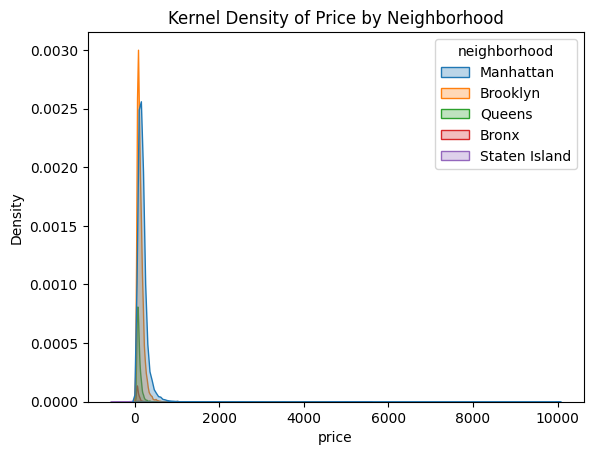

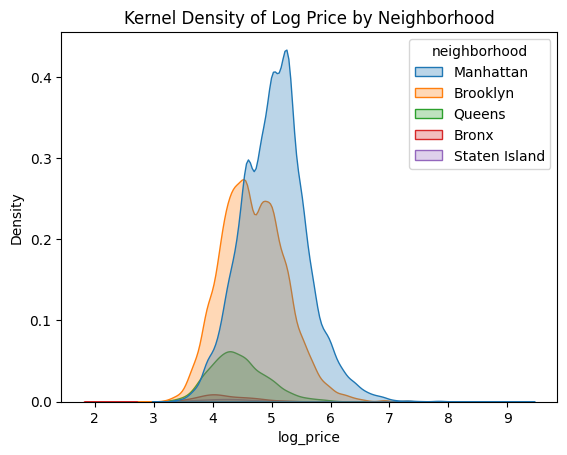

Intercept: 75.27649769585331
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64
Intercept: 60.878390657123546
Slope: 1.0208266022674763
Intercept: -23.812561011672244
Brooklyn          51.704240
Manhattan        108.228737
Queens            21.694600
Staten Island     71.766552
rating             1.081116
dtype: float64
Bronx            0.222718
Brooklyn         0.790947
Manhattan        1.399376
Queens           0.456451
Staten Island    0.682444
dtype: float64
Model 2.3 MSE: 22078.215444464753
Model 2.4 MSE: 21068.500019790663
Model 2.5 MSE: 21045.456149618978


In [7]:
rent = pd.DataFrame(pd.read_csv('Q1_clean.csv'))
rent.head()

# 2.1

# Standardize column names
rent = rent.rename(columns={
    "Price": "price",
    "Review Scores Rating": "rating",
    "Neighbourhood ": "neighborhood"
})

# Average price, rating, and listing count per neighborhood
neighborhood_stats = rent.groupby("neighborhood").agg(
    mean_price=("price", "mean"),
    mean_rating=("rating", "mean"),
    count=("price", "count")
).reset_index()

print(neighborhood_stats.sort_values("mean_price", ascending=False))

rent["log_price"] = np.log(rent["price"])

# Distribution of price across neighborhoods
sns.kdeplot(data=rent, x="price", hue="neighborhood", fill=True, alpha=0.3)
plt.title("Kernel Density of Price by Neighborhood")
plt.show()

# Distribution of log transformed price across neighborhoods
sns.kdeplot(data=rent, x="log_price", hue="neighborhood", fill=True, alpha=0.3)
plt.title("Kernel Density of Log Price by Neighborhood")
plt.show()


# 2.2

# Make neighborhood as dummies and drop Bronx as baseline
X_neighborhood = pd.get_dummies(rent["neighborhood"], drop_first=True)
y = rent["price"]

model_neighborhood = LinearRegression()
model_neighborhood.fit(X_neighborhood, y)

neighborhood_coefs = pd.Series(model_neighborhood.coef_, index=X_neighborhood.columns)
intercept = model_neighborhood.intercept_

print("Intercept:", intercept)
print(neighborhood_coefs)


# 2.3

X_rating = rent[["rating"]]
y = rent["price"]

model_rating = LinearRegression()
model_rating.fit(X_rating, y)

print("Intercept:", model_rating.intercept_)
print("Slope:", model_rating.coef_[0])

# 2.4

# Combine neighborhood dummies and rating
X_full = pd.concat([
    pd.get_dummies(rent["neighborhood"], drop_first=True),
    rent[["rating"]]
], axis=1)

y = rent["price"]

model_full = LinearRegression()
model_full.fit(X_full, y)

print("Intercept:", model_full.intercept_)
print(pd.Series(model_full.coef_, index=X_full.columns))

# 2.5

# Multiply neighborhood dummies by rating to get interaction terms
neighborhood_dummies = pd.get_dummies(rent["neighborhood"], drop_first=False)

X_interaction = neighborhood_dummies.mul(rent["rating"], axis=0)

y = rent["price"]

model_interaction = LinearRegression()
model_interaction.fit(X_interaction, y)

print(pd.Series(model_interaction.coef_, index=X_interaction.columns))

# 2.6

kf = KFold(n_splits=5, shuffle=True, random_state=1)

# Model 2.3 — rating only
mse_rating = -cross_val_score(LinearRegression(), X_rating, y,
                               scoring="neg_mean_squared_error", cv=kf).mean()

# Model 2.4 — neighborhood + rating
mse_full = -cross_val_score(LinearRegression(), X_full, y,
                             scoring="neg_mean_squared_error", cv=kf).mean()

# Model 2.5 — interaction terms
mse_interaction = -cross_val_score(LinearRegression(), X_interaction, y,
                                    scoring="neg_mean_squared_error", cv=kf).mean()

print("Model 2.3 MSE:", mse_rating)
print("Model 2.4 MSE:", mse_full)
print("Model 2.5 MSE:", mse_interaction)


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?

  - SUVs and MUVs are the most expensive body types while SUVs also show the most variance as it has a long tail.

  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

  - The intercept is 439,032 rupees and the slope is 59,268 rupees so each additional seat is associated with a 59,268 rupee increase in price. It is not roughly linear as there are wild and uneven jumps in price.

  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

  - The model accurately predicts the price of cars with age, especially if they are older. However, there is a large variance in price so individual predictions will be very noisy.


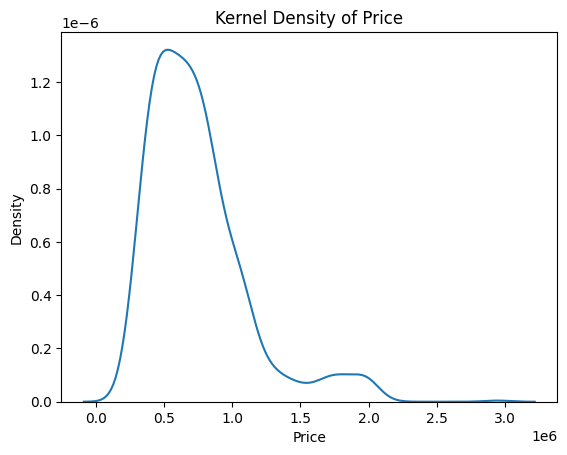

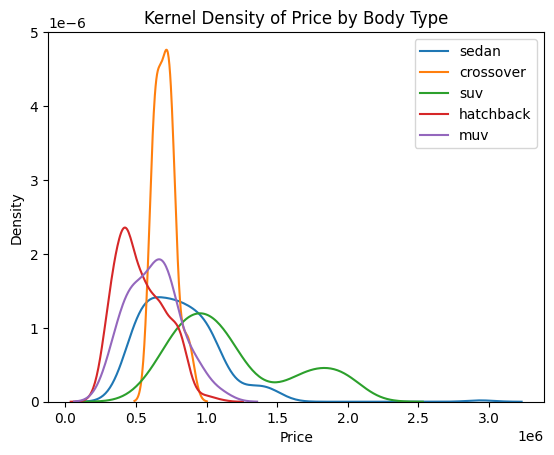

Intercept: 439032.0141018266
Slope: 59267.99803672175
5    5.464839e+05
6    1.456000e+06
7    7.359487e+05
8    2.718000e+05
dtype: float64
{1: np.float64(97745760011.44075), 2: np.float64(97815319552.31636), 3: np.float64(97304076284.38507), 4: np.float64(96785385468.5646), 5: np.float64(95816293470.71298), 6: np.float64(95922593166.28873), 7: np.float64(95270929030.95691), 8: np.float64(95555745870.38574), 9: np.float64(95558185086.32103), 10: np.float64(95333044553.1976)}


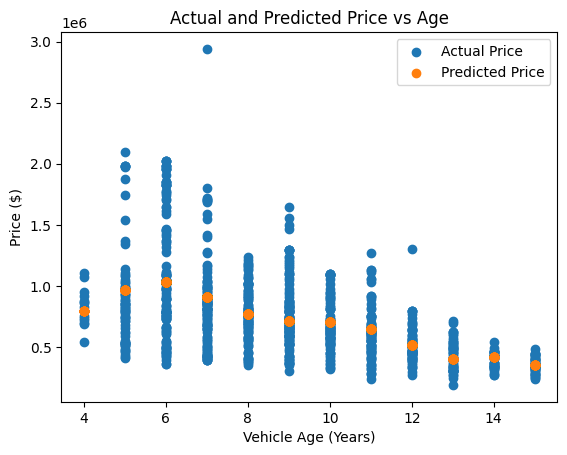

In [9]:
from sklearn.preprocessing import PolynomialFeatures

cars = pd.DataFrame(pd.read_csv('/content/data/cars_hw.csv'))
cars.head()

# 3.1

# Plot overall price distribution
sns.kdeplot(cars["Price"])
plt.title("Kernel Density of Price")
plt.show()

cars.groupby("Body_Type")["Price"].describe()

# Plot price distribution separately for each body type
plt.figure()

for b in cars["Body_Type"].unique():
    subset = cars[cars["Body_Type"] == b]
    sns.kdeplot(subset["Price"], label=b)

plt.legend()
plt.title("Kernel Density of Price by Body Type")
plt.show()

# 3.2

X = cars[["Seating_Capacity"]]
y = cars["Price"]

model_linear = LinearRegression()
model_linear.fit(X, y)

print("Intercept:", model_linear.intercept_)
print("Slope:", model_linear.coef_[0])


X_cat = pd.get_dummies(cars["Seating_Capacity"], drop_first=True)

model_cat = LinearRegression()
model_cat.fit(X_cat, y)

print(pd.Series(model_cat.coef_, index=X_cat.columns))

# 3.3

# Get vehicle age from manufacture year
current_year = 2026
cars["Age"] = current_year - cars["Make_Year"]

# Create 10-fold cross validation
kf = KFold(n_splits=10, shuffle=True, random_state=1)

y = cars["Price"]
results = {}

for degree in range(1, 11):
    poly = PolynomialFeatures(degree, include_bias=False)
    X_poly = poly.fit_transform(cars[["Age"]])

    model = LinearRegression()
    mse = -cross_val_score(model, X_poly, y,
                           scoring="neg_mean_squared_error",
                           cv=kf).mean()
    results[degree] = mse

print(results)


# 3.4

# Select degree with lowest cross-validated MSE
best_degree = 7

# Expand age into polynomial features
poly = PolynomialFeatures(best_degree, include_bias=False)
X_poly = poly.fit_transform(cars[["Age"]])

model = LinearRegression()
model.fit(X_poly, y)

cars["Predicted_Price"] = model.predict(X_poly)

# Overlay actual and predicted prices against vehicle age
plt.scatter(cars["Age"], cars["Price"], label="Actual Price")
plt.scatter(cars["Age"], cars["Predicted_Price"], label="Predicted Price")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Price ($)")
plt.title("Actual and Predicted Price vs Age")
plt.legend()
plt.show()


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

- On average, the 3 year survival rate increases by 23%.

2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

- The control condition and ATE are equal to the transplant coefficient.

3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

- When controlling for age, the transplant coefficient increases slightly which could mean ATE slightly underestimated the impact of transplants. The intercept represents predicted probability of survival for a control patient at age zero which is not useful but necessary for regression at 0.702. The age coefficient represents that as patients get older, their predicted survival probability decreases by about 1.4 percentage points per year. The model tends to over and under estimate the impacts most for ages under 35 and over 50.

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

- Allowing an interaction term lets the treatment effect vary with age, better capturing the biological reality that younger patients tend to tolerate transplants more successfully than older ones.

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

- I would be concerned with any of the MSEs of the models as they are very high compared to the ATE. This means the prediction errror is high and that it would not be very effective at individual predictions. There are also exogenous variables that have a large effect on the model such as other health conditions that could determine survivability. Deploying the model would discriminate older people as it would give them a lower likelihood of survival and as such might prevent them from receiving life saving care.


Control: 0.11764705882352941
Treatment: 0.34782608695652173
ATE: 0.23017902813299232
Intercept: 0.1176470588235293
Transplant coef: 0.23017902813299249
Intercept: 0.7019569721740947
Transplant coef: 0.2647016865036751
Age coef: -0.013607217160218647


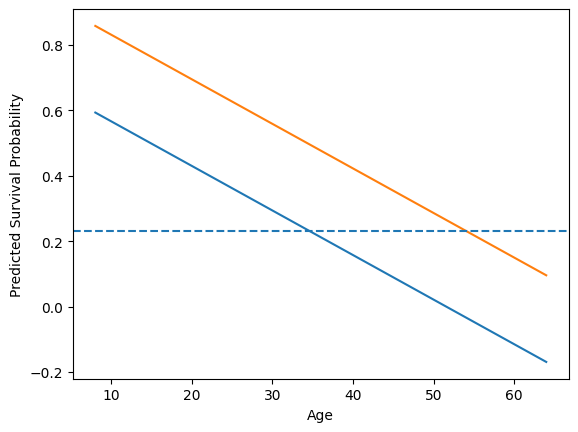

Intercept: 0.35486517529945855
Transplant coef: 0.9077513885685898
Age coef: -0.0055242575069736986
Interaction coef: -0.01459063825685528


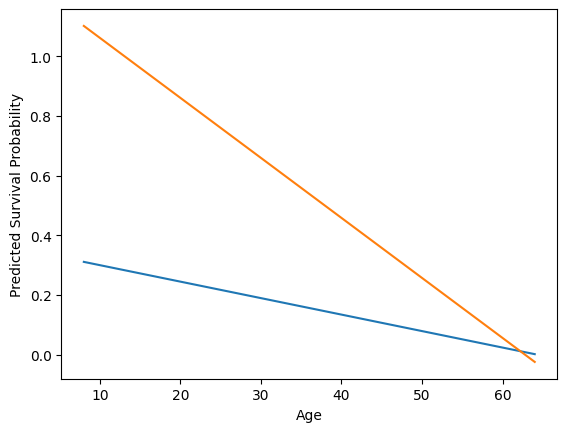

0.19497249586192156 0.17926415954952163 0.17880206762517337


In [13]:
cardiac = pd.read_csv("heart_hw.csv")
cardiac["Treatment_Flag"] = (cardiac["transplant"] == "treatment").astype(int)
cardiac.head()

# 4.1

# Compute average outcomes for each group
ctrl_mean = cardiac.loc[cardiac["Treatment_Flag"] == 0, "y"].mean()
treat_mean = cardiac.loc[cardiac["Treatment_Flag"] == 1, "y"].mean()

# Compute Average Treatment Effect
avg_treatment_effect = treat_mean - ctrl_mean

print("Control:", ctrl_mean)
print("Treatment:", treat_mean)
print("ATE:", avg_treatment_effect)

# 4.2

features = cardiac[["Treatment_Flag"]]
outcome = cardiac["y"]

reg1 = LinearRegression()
reg1.fit(features, outcome)

print("Intercept:", reg1.intercept_)
print("Transplant coef:", reg1.coef_[0])

# 4.3

features = cardiac[["Treatment_Flag", "age"]]

reg2 = LinearRegression()
reg2.fit(features, cardiac["y"])

print("Intercept:", reg2.intercept_)
print("Transplant coef:", reg2.coef_[0])
print("Age coef:", reg2.coef_[1])

age_grid = np.linspace(cardiac["age"].min(), cardiac["age"].max(), 100)

# Compute predicted values for control and treatment groups
pred_ctrl = reg2.intercept_ + reg2.coef_[1] * age_grid
pred_trt = pred_ctrl + reg2.coef_[0]

plt.plot(age_grid, pred_ctrl)
plt.plot(age_grid, pred_trt)
plt.axhline(y=avg_treatment_effect, linestyle="--")
plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.show()

# 4.4

cardiac["Trt_Age_Interaction"] = cardiac["Treatment_Flag"] * cardiac["age"]

features = cardiac[["Treatment_Flag", "age", "Trt_Age_Interaction"]]

# Fit regression model with interaction term
reg3 = LinearRegression()
reg3.fit(features, cardiac["y"])

print("Intercept:", reg3.intercept_)
print("Transplant coef:", reg3.coef_[0])
print("Age coef:", reg3.coef_[1])
print("Interaction coef:", reg3.coef_[2])

# Compute predicted values for interaction
pred_ctrl = reg3.intercept_ + reg3.coef_[1] * age_grid

pred_trt = (
    reg3.intercept_
    + reg3.coef_[0]
    + reg3.coef_[1] * age_grid
    + reg3.coef_[2] * age_grid
)

plt.plot(age_grid, pred_ctrl)
plt.plot(age_grid, pred_trt)
plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.show()

# 4.5

# Cross-validated MSE for model with treatment only
cv_mse1 = -cross_val_score(reg1, cardiac[["Treatment_Flag"]], cardiac["y"],
                        scoring="neg_mean_squared_error",
                        cv=kf).mean()

# Cross-validated MSE for model with treatment and age
cv_mse2 = -cross_val_score(LinearRegression(),
                        cardiac[["Treatment_Flag", "age"]],
                        cardiac["y"],
                        scoring="neg_mean_squared_error",
                        cv=kf).mean()

# Cross-validated MSE for model with treatment, age, and interaction
cv_mse3 = -cross_val_score(LinearRegression(),
                        cardiac[["Treatment_Flag", "age", "Trt_Age_Interaction"]],
                        cardiac["y"],
                        scoring="neg_mean_squared_error",
                        cv=kf).mean()
print(cv_mse1, cv_mse2, cv_mse3)